# Message Framing — an A/B experiment with randomization

**The study.** A between-subjects survey experiment: respondents are randomly assigned to read one of two texts (a statistics frame or a personal story) and then answer the same outcome questions. The design needs random assignment at the start, a text that only the assigned arm sees, counterbalanced outcome order, a timed manipulation check, an attention check, and a debrief.

**What this notebook shows.** An `onInit` script that assigns a condition and stores it with the response; string gates for script-set variables; `ContentPage` vignettes; `Block(randomize=True)`; `SingleChoice(randomize=True)`; `Script.timed_question`; an `onSubmit` script with `context`; a real local deployment; rehearsing the analysis when `simulate()` cannot run scripts; two-group tests chosen by measurement scale.

> In the cookbook this instrument was driven end to end in headless Chromium: both arms occurred, only the assigned vignette was visible, and `condition`, the `onSubmit` stamps and `__timers__` were stored with each response.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

import siamang as sg
from siamang.core import ContentPage, DisqualificationPage, FinalPage

from siamang.reporting.tables import CrossTable, FreqTable, GroupMeanTable
for _cls in (FreqTable, CrossTable, GroupMeanTable):   # text/plain fallback = Markdown table; the HTML view is unchanged
    get_ipython().display_formatter.formatters["text/plain"].for_type(_cls, lambda t, p, cycle: p.text(t.to_markdown()))
OUT = Path("out"); OUT.mkdir(exist_ok=True)
print("siamang", sg.__version__)

siamang 0.6.0


## 1. Codebook

In [2]:
AGREE7 = {1: "Strongly disagree", 2: "Disagree", 3: "Somewhat disagree", 4: "Neither",
          5: "Somewhat agree", 6: "Agree", 7: "Strongly agree"}

condition = sg.Variable("condition", scale="nominal", label="Experimental condition",
                        labels={1: "Control (statistics frame)", 2: "Treatment (story frame)"}, role="grouping")
age = sg.Variable("age", scale="ratio", label="Age", dtype="int", valid_range=(18, 99))
gender = sg.Variable("gender", scale="nominal", label="Gender", labels={1: "Woman", 2: "Man", 3: "Other"})
politics = sg.Variable("politics", scale="ordinal", label="Political orientation (1 left - 7 right)",
                       labels={i: str(i) for i in range(1, 8)})
attention = sg.Variable("attention", scale="nominal", label="Attention check",
                        labels={1: "Strongly disagree", 2: "Disagree", 3: "Somewhat agree", 4: "Strongly agree"})
support = sg.Variable("support", scale="ordinal", label="Support for the policy", labels=AGREE7, role="target")
donate = sg.Variable("donate", scale="ratio", label="Hypothetical donation (EUR, 0-100)",
                     dtype="int", valid_range=(0, 100), role="target")
manip_check = sg.Variable("manip_check", scale="ordinal", label="The message focused on one person's story", labels=AGREE7)
issue = sg.Variable("issue", scale="nominal", label="Most important issue",
                    labels={1: "Housing", 2: "Climate", 3: "Health care", 4: "Education"})

variables = sg.VariableMap()
variables.add_many([condition, age, gender, politics, attention, support, donate, manip_check, issue])
print(len(variables), "variables")

9 variables


## 2. Scripts and the instrument

Why the vignette gate is a plain string: `validate()` resolves typed expressions and `{name}` tokens against the variables bound to *questions*. `condition` is bound to none, so `show_if=condition.eq(1)` fails with "references unknown variables". A brace-less string such as `"condition = 1"` is passed through; the React runtime treats the bare word as a variable and re-evaluates page visibility whenever the answers store changes — including the write from the `onInit` script.

`utils.shuffle([1, 2])[0]` picks one arm; `utils.sample(arr, n)` returns an *array*, so `utils.sample([1, 2])` would assign both.

In [3]:
assign = sg.Script(
    name="assign_condition", trigger="onInit",
    code="if (answers.condition == null) { answers.condition = utils.shuffle([1, 2])[0]; }",
)
timer = sg.Script.timed_question("manip_check", seconds=45)
stamp = sg.Script(
    name="stamp_submission", trigger="onSubmit", context={"study": "framing-2026"},
    code="answers.study = context.study; answers.submitted_client_time = utils.now();",
)

STATS_FRAME = ("<h3>Housing in numbers</h3><p>Last year 41,000 households applied for social "
               "housing; 12% received a home within twelve months.</p>")
STORY_FRAME = ("<h3>Maria's year</h3><p>Maria, a nurse and mother of two, spent last year on "
               "a waiting list, moving between relatives' sofas while she waited for a home.</p>")

survey = sg.Questionnaire(
    title="Public Attitudes to Housing Policy",
    variables=variables,
    scripts=[assign, timer, stamp],
    pages=[
        ContentPage("intro", title="About this study",
                    body="<p>You will read a short text and answer a few questions (4 minutes).</p>"),
        sg.Page("demographics", title="About you", items=[
            sg.NumericInput("How old are you?", var=age, required=True),
            sg.SingleChoice("Gender", var=gender, display="buttons"),
            sg.LikertScale("In politics people sometimes talk of left and right. Where would you place yourself?",
                           var=politics, points=7, left_label="Left", right_label="Right"),
            sg.SingleChoice("Which issue matters most to you right now?", var=issue, randomize=True),
        ]),
        ContentPage("vignette_control", title="Please read carefully", body=STATS_FRAME, show_if="condition = 1"),
        ContentPage("vignette_treatment", title="Please read carefully", body=STORY_FRAME, show_if="condition = 2"),
        sg.Page("outcomes", title="Your view", items=[
            sg.Block(randomize=True, items=[                              # counterbalance the two outcomes
                sg.LikertScale("The government should build more social housing.", var=support, points=7,
                               left_label="Strongly disagree", right_label="Strongly agree", required=True),
                sg.NumericInput("If you received EUR 100 today, how much would you give to a housing charity?",
                                var=donate, display="slider", step=5),
            ]),
            sg.SingleChoice("To show you are reading, please select 'Somewhat agree'.", var=attention, required=True),
        ]),
        sg.Page("checks", title="One last question", items=[
            sg.LikertScale("The text I read focused on one person's story.", var=manip_check, points=7,
                           left_label="Strongly disagree", right_label="Strongly agree"),
        ]),
        DisqualificationPage("failed_attention", title="Thank you",
                             body="<p>Unfortunately we cannot use your answers.</p>", show_if=attention.ne(3)),
        FinalPage("thanks", title="Thank you",
                  body="<p>Debrief: the text you read was one of two versions assigned at random.</p>"),
    ],
)
options = {"completion_text": "Thank you for taking part.", "metadata": {"design": "2-arm"}}

survey.validate(strict=True)
print("strict lint (a warning only — condition is filled by the onInit script):",
      [f"{w.severity}:{w.code}({w.location})" for w in survey.lint(level="strict")])
try:                                                                    # demonstration
    sg.Questionnaire(title="typed gate", variables=variables, pages=survey.pages[:2] + [
        ContentPage("v", body="x", show_if=condition.eq(1))]).validate()
except ValueError as e:
    print("EXPECTED (demonstration) — a typed gate on the script-set variable is rejected:", e)

strict lint (a warning only — condition is filled by the onInit script): ['warning:UNUSED_VARIABLE(condition)']
EXPECTED (demonstration) — a typed gate on the script-set variable is rejected: Page 'v' show_if references unknown variables: condition


## 3. Local deployment: what a submission looks like

The runtime posts the whole answers store — here two submissions as the browser would send them after the scripts ran (one per arm).

In [4]:
result = survey.deploy(backend_kwargs={"path": str(OUT / "framing.db")}, frontend_kwargs={"host": "127.0.0.1"}, **options)
for arm, sup in ((1, 4), (2, 6)):
    answers = {"condition": arm, "age": 31, "gender": 2, "politics": 4, "issue": 1, "support": sup, "donate": 40,
               "attention": 3, "manip_check": 5, "study": "framing-2026", "submitted_client_time": 1788376764216,
               "__options__": {}, "__pages__": [], "__errors__": {}, "__timers__": {"manip_check": 45}}
    print(requests.post(f"{result.url}/responses", json={"survey_id": result.survey_id, "responses": answers}, timeout=5).json())
raw = result.collect()
result.frontend_ref.stop()
print(list(raw.columns))
raw.loc[:, ~raw.columns.str.startswith("__")]

{'ok': True, 'response_id': 1}
{'ok': True, 'response_id': 2}
['condition', 'age', 'gender', 'politics', 'issue', 'support', 'donate', 'attention', 'manip_check', 'study', 'submitted_client_time', '__options__', '__pages__', '__errors__', '__timers__', '_response_id', '_submitted_at']


,condition,age,gender,politics,issue,support,donate,attention,manip_check,study,submitted_client_time,_response_id,_submitted_at
0,1,31,2,4,1,4,40,3,5,framing-2026,1788376764216,1,2026-09-03 01:59:21
1,2,31,2,4,1,6,40,3,5,framing-2026,1788376764216,2,2026-09-03 01:59:21


## 4. Rehearsal data

`simulate()` yields no `condition` column (no scripts run) and treats string gates as always true → assign the arm in pandas with `with_frame()`. The registry gives the arms their labels. A small artificial effect is added so the tables show something.

In [5]:
data = survey.simulate(n=400, seed=11)
rng = np.random.default_rng(11)
frame = data.frame.assign(condition=rng.choice([1, 2], size=len(data.frame)))
frame.loc[frame["condition"] == 2, "support"] = frame.loc[frame["condition"] == 2, "support"].clip(upper=6) + 1
data = data.with_frame(frame)

n0 = len(data.frame)
data = data.with_frame(data.frame[data.frame["attention"] == 3].reset_index(drop=True))
print(f"attention check: kept {len(data.frame)} of {n0} (synthetic answers are uniform; real data keeps far more)")
data.report.freq("condition")

attention check: kept 103 of 400 (synthetic answers are uniform; real data keeps far more)


Value,Label,N,%,Cumulative %
1,Control (statistics frame),50,48.5,48.5
2,Treatment (story frame),53,51.5,100.0
,Total,103,100.0,100.0


## 5. Balance checks and treatment effects

`data.report.means()` picks Mann–Whitney for the ordinal `support` and an independent t-test for the ratio-scaled `donate` because there are two groups; with three arms the same calls run Kruskal–Wallis and ANOVA.

In [6]:
data.report.crosstab("condition", "gender", pct="row")      # balance: χ² should be n.s.

Experimental condition,Woman,Man,Other,Total
Control (statistics frame),30.0,42.0,28.0,50
Treatment (story frame),34.0,30.2,35.8,53
Total,33.0,37.0,33.0,103


In [7]:
data.report.means("age", by="condition")                    # balance: t-test

Experimental condition,Mean,SD,Median,N
Control (statistics frame),59.180,21.13,58.0,50
Treatment (story frame),52.698,25.07,45.0,53


In [8]:
data.report.means("support", by="condition")                # ordinal, 2 groups → Mann-Whitney U

Experimental condition,Mean,SD,Median,N
Control (statistics frame),4.060,2.123,4.5,50
Treatment (story frame),4.755,1.697,5.0,53


In [9]:
data.report.means("donate", by="condition")                 # ratio, 2 groups → t-test

Experimental condition,Mean,SD,Median,N
Control (statistics frame),49.640,29.792,47.5,50
Treatment (story frame),42.151,31.289,39.0,53


In [10]:
print(data.analysis.mannwhitney("support", "condition"))
data = data.derive(name="supports", expression=support.ge(5), label="Supports the policy (5-7)", labels={0: "No", 1: "Yes"})
for arm in (1, 2):
    arm_data = data.with_frame(data.frame[data.frame["condition"] == arm])
    ci = arm_data.analysis.proportion_ci("supports", value=1)
    print(f"arm {arm}: support {ci['p']:.1%} [{ci['lower']:.1%}, {ci['upper']:.1%}]")
data.report.means("manip_check", by="condition")            # manipulation check

{'statistic': 1066.5, 'p_value': 0.08479996623693861, 'group_a': 1, 'group_b': 2}
arm 1: support 50.0% [36.1%, 63.9%]
arm 2: support 52.8% [39.4%, 66.3%]


Experimental condition,Mean,SD,Median,N
Control (statistics frame),3.860,1.959,4.0,50
Treatment (story frame),4.434,1.937,4.0,53


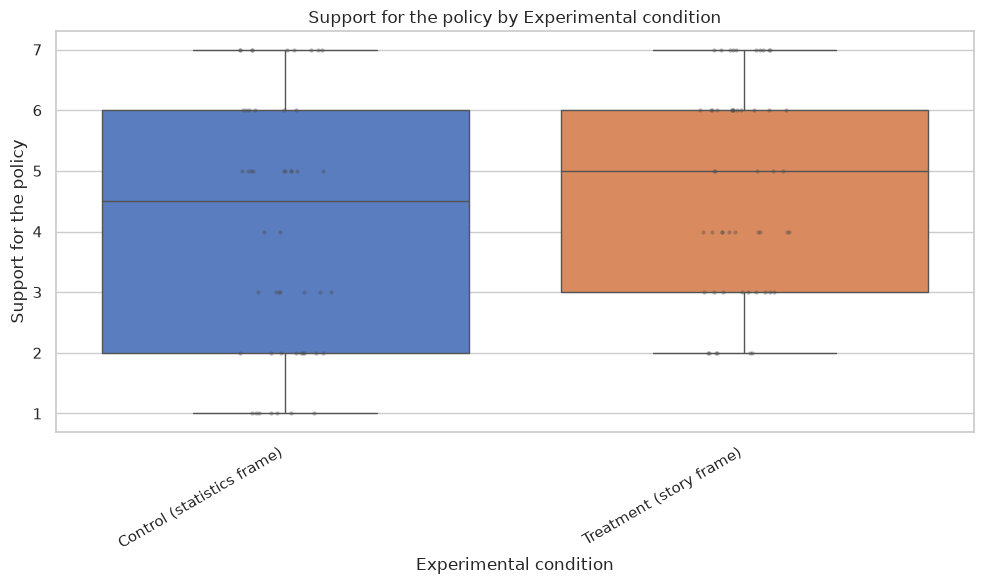

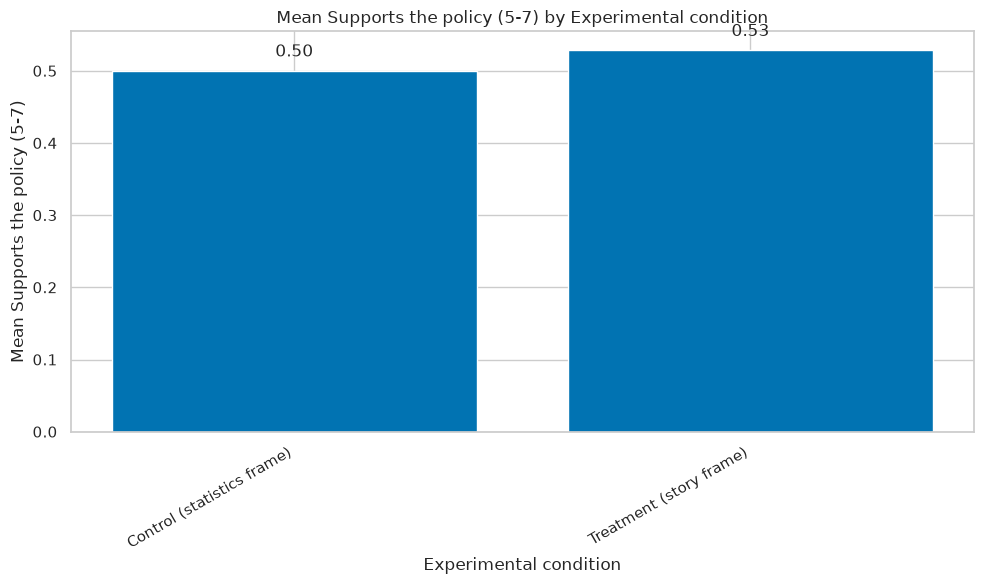

In [11]:
data.plot.boxplot("support", by="condition", show_points=True).plot(); plt.show()
data.plot.bar("supports", by="condition", palette="colorblind").plot(); plt.show()

## 6. Report

In [12]:
report = (
    sg.Report(title="Framing experiment — results", description="Between-subjects, 2 arms")
    .heading("Design").value("Analysed respondents", len(data.frame))
    .add(data.report.crosstab("condition", "gender"), caption="Table 1. Balance: gender by arm")
    .heading("Effects")
    .add(data.report.means("support", by="condition"), caption="Table 2. Policy support by arm")
    .add(data.plot.boxplot("support", by="condition", show_points=True), caption="Figure 1. Support by arm")
    .add(data.report.crosstab("condition", "supports", pct="row"), caption="Table 3. Share supporting the policy by arm")
    .note("Respondents failing the attention check were excluded before analysis.")
)
report.save(OUT / "framing_report.md")
plt.close("all")
print(report.to_markdown(asset_dir=OUT)[:1000])

# Framing experiment — results

*Between-subjects, 2 arms*

## Design

**Analysed respondents:** 103

*Table 1. Balance: gender by arm*

| Experimental condition | Woman | Man | Other | Total |
|---|---|---|---|---|
| Control (statistics frame) | 15 | 21 | 14 | 50 |
| Treatment (story frame) | 18 | 16 | 19 | 53 |
| Total | 33 | 37 | 33 | 103 |

χ² = 1.6200; df = 2; p = 0.4449; Cramér's V = 0.1250; N = 103

## Effects

*Table 2. Policy support by arm*

| Experimental condition | Mean | SD | Median | N |
|---|---|---|---|---|
| Control (statistics frame) | 4.06 | 2.123 | 4.5 | 50 |
| Treatment (story frame) | 4.755 | 1.697 | 5.0 | 53 |

Mann-Whitney U = 1066.5000; p = 0.0848; N = 103; Variable = Support for the policy

![Figure 1. Support by arm](fig_5.png)

*Figure 1. Support by arm*

*Table 3. Share supporting the policy by arm*

| Experimental condition | No | Yes | Total |
|---|---|---|---|
| Control (statistics frame) | 50.0 | 50.0 | 50 |
| Treatment (story frame) | 47.2 | 52.8 | 53